# **1. Perkenalan Dataset**


**Sumber Dataset**: ttps://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset



# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

In [7]:
df = pd.read_csv('../dataset_raw/Churn_Modelling.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **4. Exploratory Data Analysis (EDA)**

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


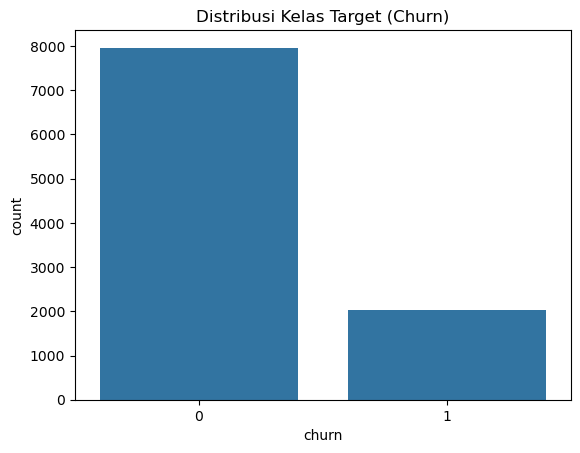

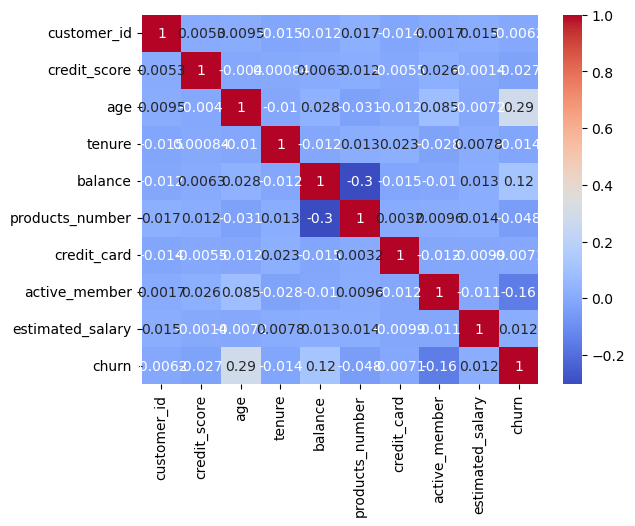

In [8]:
# Cek missing values
print(df.isnull().sum())

# Cek distribusi target (churn)
sns.countplot(x='churn', data=df)
plt.title('Distribusi Kelas Target (Churn)')
plt.show()

# Korelasi antar fitur numerik
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()


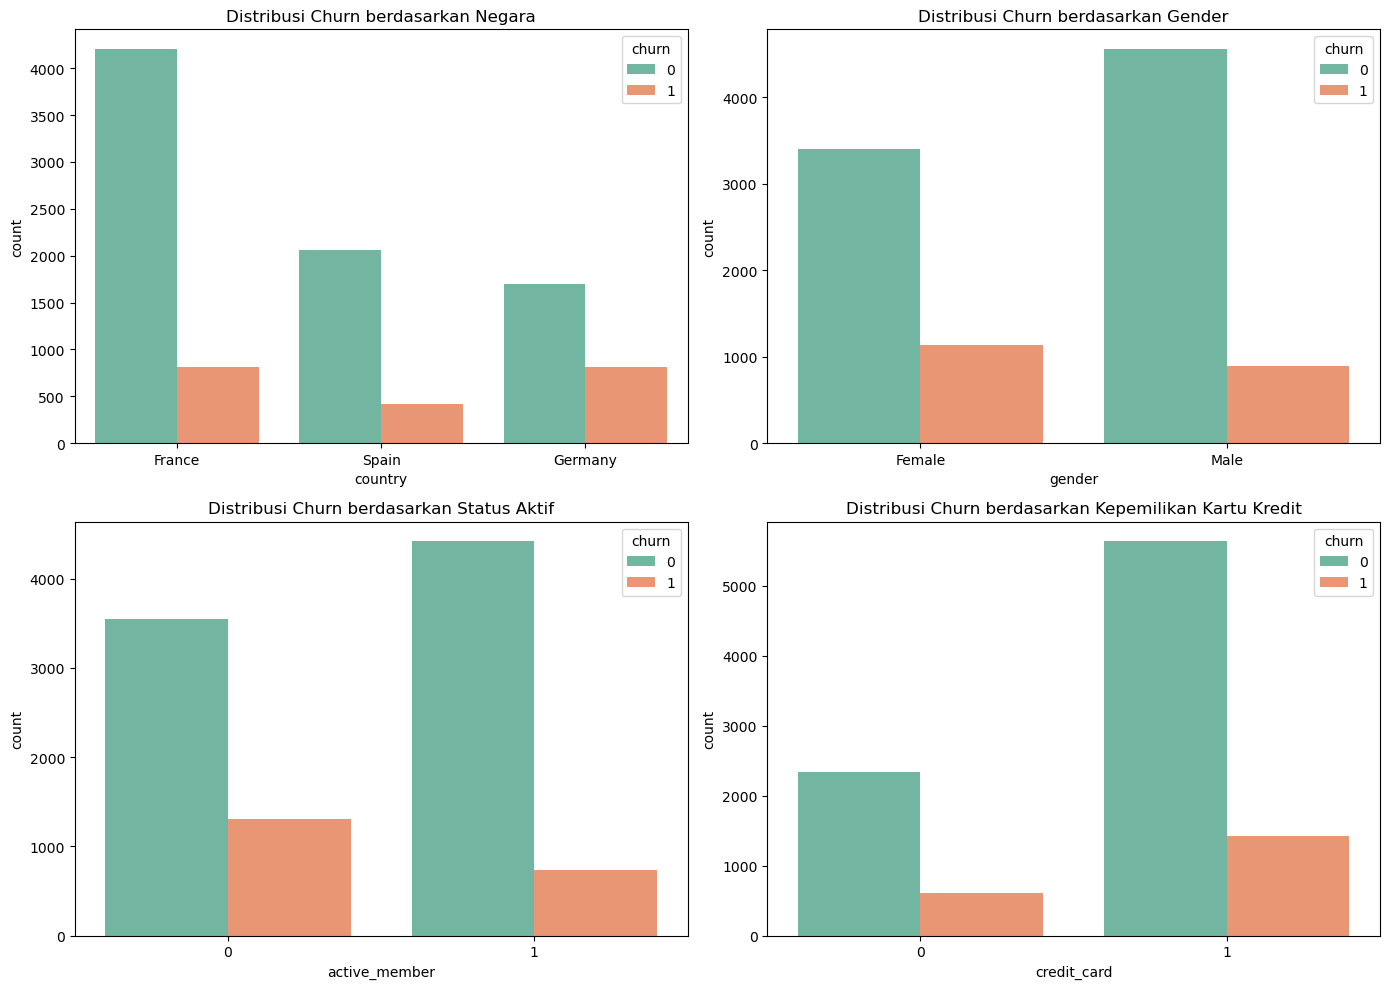

In [ ]:
# Analisis Fitur Kategorikal terhadap Target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='country', hue='churn', data=df, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Distribusi Churn berdasarkan Negara')

sns.countplot(x='gender', hue='churn', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Distribusi Churn berdasarkan Gender')

sns.countplot(x='active_member', hue='churn', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Distribusi Churn berdasarkan Status Aktif')

sns.countplot(x='credit_card', hue='churn', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Distribusi Churn berdasarkan Kepemilikan Kartu Kredit')

plt.tight_layout()
plt.show()

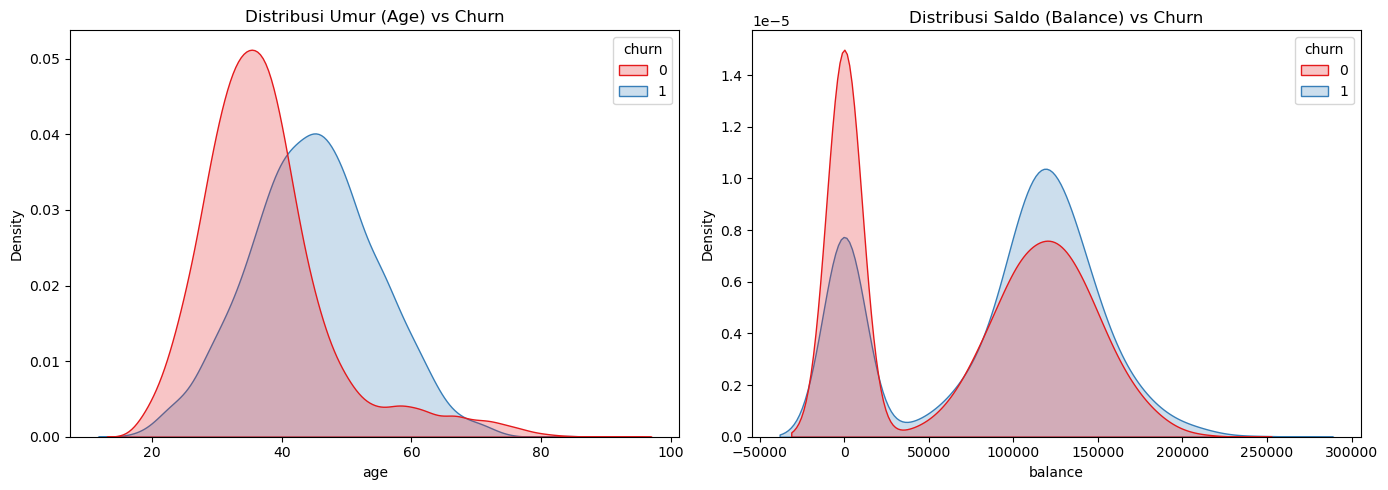

In [11]:
# Distribusi Fitur Numerik terhadap Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='age', hue='churn', fill=True, ax=axes[0], palette='Set1', common_norm=False)
axes[0].set_title('Distribusi Umur (Age) vs Churn')

sns.kdeplot(data=df, x='balance', hue='churn', fill=True, ax=axes[1], palette='Set1', common_norm=False)
axes[1].set_title('Distribusi Saldo (Balance) vs Churn')

plt.tight_layout()
plt.show()

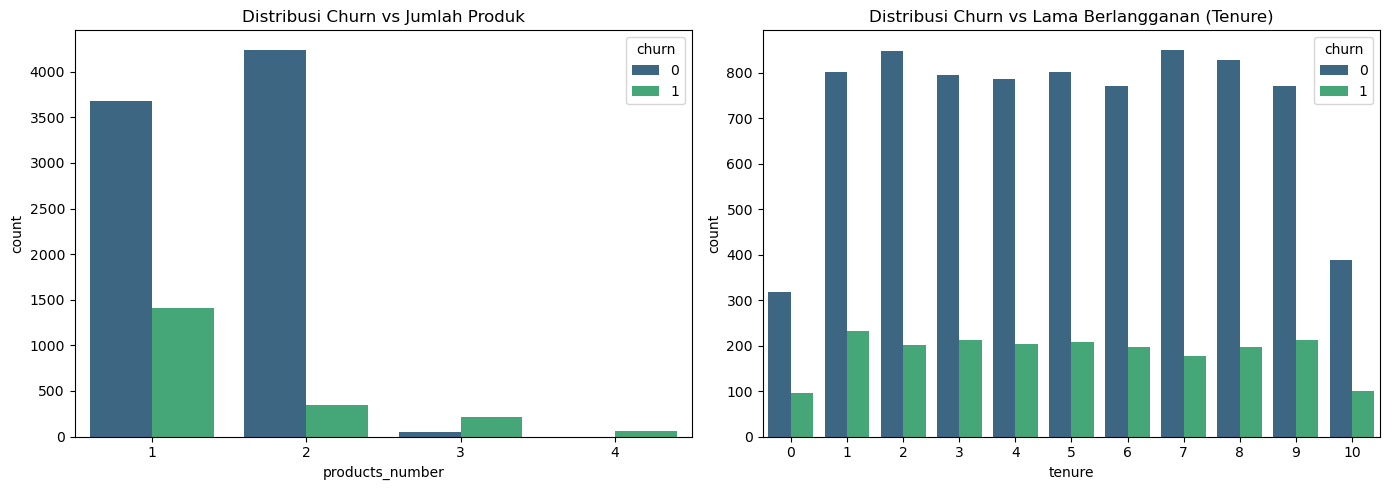

In [13]:
# Analisis Karakteristik Produk dan Loyalitas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='products_number', hue='churn', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Churn vs Jumlah Produk')

sns.countplot(x='tenure', hue='churn', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Distribusi Churn vs Lama Berlangganan (Tenure)')

plt.tight_layout()
plt.show()

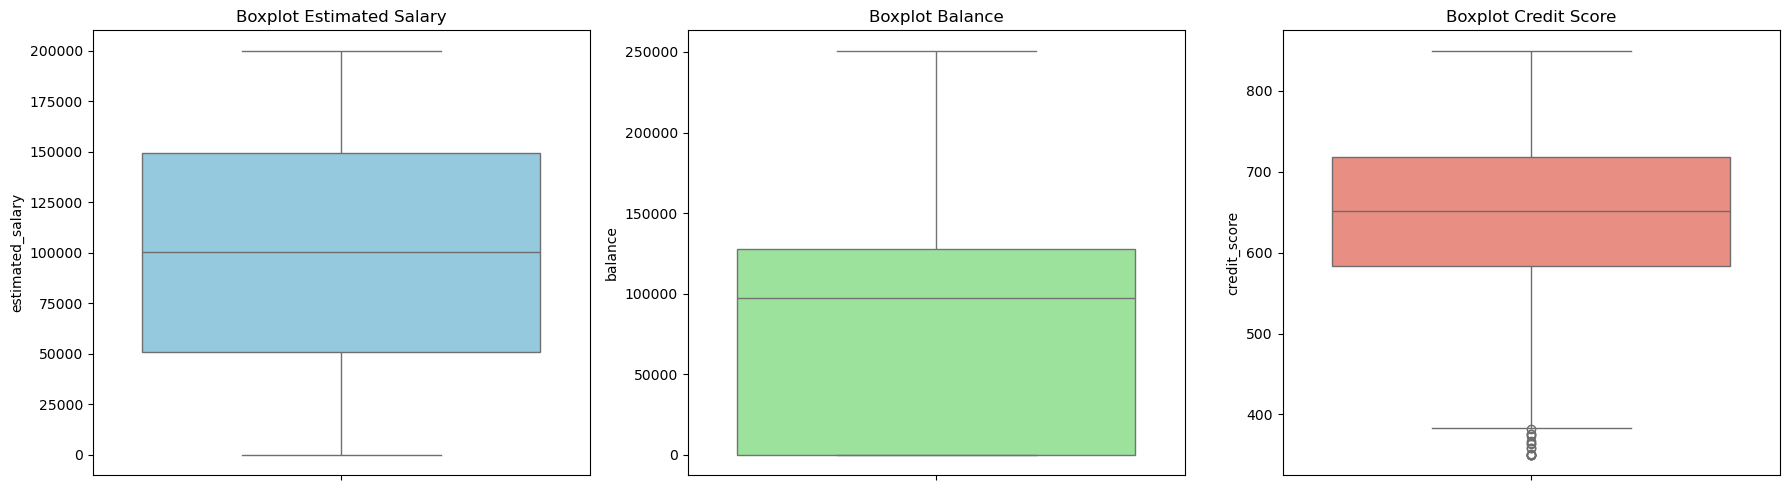

In [14]:
# Deteksi Outlier pada Fitur Numerik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y='estimated_salary', data=df, ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot Estimated Salary')

sns.boxplot(y='balance', data=df, ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Balance')

sns.boxplot(y='credit_score', data=df, ax=axes[2], color='salmon')
axes[2].set_title('Boxplot Credit Score')

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

In [15]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop kolom yang tidak relevan (tidak memiliki nilai prediktif)
df_clean = df.drop(columns=['customer_id'])

# Encoding Kategorikal
# 'gender' (Male/Female) -> Binary
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])

# 'country' (France, Spain, Germany) -> One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=['country'], drop_first=True)

# Scaling Numerikal
scaler = StandardScaler()
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
df_clean.head()

# Simpan ke folder dataset_preprocessing
df_clean.to_csv('../dataset_preprocessing/dataset_clean.csv', index=False)
